In [1]:
import zenidatasdk as zd
import alphalens
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import time
import os

pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
# 检查版本
print(f"ZeniData SDK版本: {zd.__version__}")

# 创建客户端（测试基础功能）
client = zd.Client()
print("✅ 客户端创建成功")

# 登录账号，初始化 client 对象
client = zd.Client(
    username = "3191883175@qq.com",
    password = "Abc123456",
    base_url = "http://192.168.1.100:8000")
print("✅ 登录成功")

ZeniData SDK版本: 2.0.6
✅ 客户端创建成功
✅ 登录成功


In [3]:
start_date =  "2016-01-01"                          # 定义所要回测的起始日期
current_day = str(datetime.datetime.now().date())   # 使用现在作为结束日期
get_index_constituents_df = (                       # 定义快捷的指数成分股表格获取
    lambda index: client.get_index_constituents_df(index, start_date = start_date, end_date = current_day)
)

core_index_constituents_dict = {
    index_code: get_index_constituents_df(index_code)
    for index_code in [
        rf"000300.XSHG",  # 沪深300
        rf"000905.XSHG",  # 中证500
        rf"000852.XSHG",  # 中证1000
        rf"000016.XSHG",  # 上证50
        rf"399006.XSHE",  # 创业板
    ]
}

HS300 = core_index_constituents_dict[rf"000300.XSHG"]  # 沪深300
ZZ500 = core_index_constituents_dict[rf"000905.XSHG"]  # 中证500
ZZ1000 = core_index_constituents_dict[rf"000852.XSHG"]  # 中证1000
SZ50 = core_index_constituents_dict[rf"000016.XSHG"]  # 上证50
CYB = core_index_constituents_dict[rf"399006.XSHE"]  # 创业板
# HS300.set_index(['datetime', 'symbol']).index.to_frame(index = False) # 把 index 复制一份作为列以生成表格
display(HS300.head())

symbols_df = client.get_symbols_df()  # 股票全集
display(symbols_df.head())

# symbols_df.info()
# print(symbols_df.head())
# print(symbols_df.tail())
#
# HS300.info()
# print(HS300.head())
# print(HS300.tail())

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2016-01-04,000300.XSHG,2015-12-31,000001.XSHE,0.698,平安银行
1,2016-01-04,000300.XSHG,2015-12-31,000002.XSHE,1.929,万科A
2,2016-01-04,000300.XSHG,2015-12-31,000009.XSHE,0.233,中国宝安
3,2016-01-04,000300.XSHG,2015-12-31,000027.XSHE,0.119,深圳能源
4,2016-01-04,000300.XSHG,2015-12-31,000039.XSHE,0.158,中集集团


,symbol,name,short_name,start_date,end_date,update_time
0,000001.XSHE,平安银行,PAYH,1991-04-03,2200-01-01,2026-04-14 15:15:01.500
1,000002.XSHE,万科A,WKA,1991-01-29,2200-01-01,2026-04-14 15:15:01.500
2,000004.XSHE,*ST国华,*STGH,1990-12-01,2200-01-01,2026-04-14 15:15:01.500
3,000005.XSHE,ST星源,STXY,1990-12-10,2024-04-25,2026-04-14 15:15:01.500
4,000006.XSHE,深振业A,SZYA,1992-04-27,2200-01-01,2026-04-14 15:15:01.500


In [4]:
# bars_df = client.get_bars(  # 则获取股票 OHLCV 数据
#     symbol = rf"000001.XSHE",
#     start_date = start_date,
#     end_date = current_day,
#     frequency = '1d',
#     adjust_type = 'post',
#     market = 'cn_stock'
# )
# bars_df.info()  # 查看最后一个股票的结构
# print(bars_df.head())  # 打印 DataFrame 的首尾
# print(bars_df.tail())  # 用于 copy/paste 方便询问 ai

# 定义需要的列
OHLCV_columns = ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'amount']

def fetch_stock_data(symbol_info):
    """获取单只股票数据并预处理"""
    symbol = symbol_info['symbol']
    bars_date = client.get_bars(
        symbol = symbol,
        start_date = start_date,
        end_date = current_day,
        frequency = '1d',
        adjust_type = 'post',
        market = 'cn_stock'
    )

    if bars_date is None or bars_date.empty:
        return None

    bars_date = bars_date[OHLCV_columns].copy() # 只保留需要的列，减少内存占用
    bars_date = bars_date.set_index(['datetime', 'symbol'])  # 立即设置索引
    return bars_date

In [ ]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed # concurrent.futures 是 Python 标准库中的一个模块，用于实现异步并行任务处理。
# ThreadPoolExecutor：基于线程池，适合 I/O 密集型任务
# ProcessPoolExecutor：基于进程池，适合 CPU 密集型任务

# Future 对象，代表异步操作的的结果容器。其状态不是属性而被设计为方法
#     future.cancelled(): 在队列中等待分配线程
#     future.running(): 正在某个 Worker 线程中执行
#     future.done(): 已完成，即有结果或异常

# Executor 类，管理任务执行
# as_completed()，按完成顺序获取结果
# wait()，等待任务完成

MAX_WORKERS = 4  # 线程池大小，根据 API 限流调整
data_chunks = [] # 数据块列表

with ThreadPoolExecutor(max_workers = MAX_WORKERS) as executor:
    # 提交所有任务
    future_to_symbol = {
        executor.submit(fetch_stock_data, row): row['symbol']
        for _, row in symbols_df.iterrows()
    }
    # executor.submit(function, *args)，将函数 fetch_stock_data 提交到线程池队列，立即返回一个 Future 对象，不等待执行完成
    # future_to_symbol 字典键为 Future 对象，即异步操作的结果容器
    # 值为对应的股票代码

    # 收集结果
    for future in tqdm(as_completed(future_to_symbol), total = len(symbols_df)):
        # as_completed(future_dict) 谁先完成就返回谁，不按提交顺序，
        # 当第 1000 只股票还在慢速下载时，第 1001 只可能已经完成了，as_completed 不会阻塞等待第 1000 只，而是立即 yield 第 1001 只的 Future
        # 如果用 future_list = list(future_to_symbol.keys()) 然后顺序遍历，就会阻塞等待每只按顺序完成
        result = future.result()
        if result is not None:
            data_chunks.append(result)

print(rf"Merging {len(data_chunks)} chunks...")
big_df = pd.concat(data_chunks, axis = 0)
big_df = big_df.sort_index() # 确保索引有序，提高后续查询效率

print(f"Final DataFrame shape: {big_df.shape}")
print(f"Memory usage: {big_df.memory_usage().sum() / 1024**2:.2f} MB")

In [5]:
if 'big_df' in locals():
    big_df.to_csv(r"C:\Users\zy\Desktop\tmp_Dataset\big_df.csv", index = True)
    pass
else:
    big_df = pd.read_csv(r"C:\Users\zy\Desktop\tmp_Dataset\big_df.csv")
    big_df['datetime'] = pd.to_datetime(big_df['datetime'])
    big_df = big_df.set_index(['datetime', 'symbol'])

In [7]:
print(big_df.head())

                           open     high      low    close      volume       amount
datetime   symbol                                                                  
2016-01-04 000001.XSHE  1123.91  1126.72  1051.79  1061.16   601648.41  660376128.0
           000002.XSHE  2892.93  2892.93  2892.93  2892.93        0.00          0.0
           000004.XSHE   341.77   346.98   307.59   307.59   306658.61   97674864.0
           000005.XSHE   102.23   102.23    92.42    92.42  3163517.95  302240960.0
           000006.XSHE   476.84   479.34   431.07   431.90   559621.04  254639760.0


In [8]:
# ================ 生成 alphalens 要求的价格表参数 ================

big_df_reset = big_df.reset_index()  # big_df 为复数索引，先把时间与股票代码重置为列
prices_for_alphalens = big_df_reset[ # 再透视为 alphalens 要求的格式
    ['datetime', 'symbol', 'open']
].pivot(
    index = 'datetime',
    columns = 'symbol',
    values = 'open'
)
prices_for_alphalens.head(60).T.head(10).T # 取一小片数据以演示格式

symbol,000001.XSHE,000002.XSHE,000004.XSHE,000005.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE
datetime,,,,,,,,,,
2016-01-04,1123.91,2892.93,341.77,102.23,476.84,191.15,313.85,109.47,135.06,50.80
2016-01-05,1055.54,2892.93,279.22,83.42,401.53,191.15,255.99,90.82,113.92,43.35
2016-01-06,1069.59,2892.93,287.42,91.19,418.59,191.15,290.33,95.63,114.19,43.87
2016-01-07,1068.65,2892.93,286.67,92.42,421.50,191.15,284.79,94.47,116.45,43.70
2016-01-08,1049.92,2892.93,261.58,88.02,396.12,191.15,271.58,90.02,109.93,41.08
2016-01-11,1030.25,2892.93,255.40,83.42,386.96,191.15,263.92,85.09,103.69,39.16
2016-01-12,1014.33,2892.93,236.56,76.37,355.34,191.15,263.65,79.24,96.77,35.66
2016-01-13,1019.95,2892.93,238.27,77.69,354.92,191.15,255.20,79.78,98.24,36.71
2016-01-14,991.85,2892.93,215.64,70.54,341.19,191.15,224.55,73.63,88.27,33.91


In [9]:
# ================  生成 zylh 规范的因子计算函数  ==================

def f_momentum20D_001(bars: pd.DataFrame, f_name = 'f_0001', min_periods: int = 20) -> pd.DataFrame:
    """
    factor_intro: 1个月动量因子，20日收益率
    category: momentum
    category_intro: 动量类因子
    subcategory: short_term_momentum
    subcategory_intro: 短期动量
    min_periods: 20
    source: None
    author: 魏丰协

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期，默认为20（1个月交易日）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """
    close_2dim = bars.reset_index()[                                        # 透视为二维交叉表
        ['datetime', 'symbol', 'close']
    ].pivot(
        index = 'datetime',
        columns = 'symbol',
        values = 'close'
    )
    close_2dim = close_2dim.ffill()
    momentum_2dim = close_2dim.pct_change(periods = min_periods)            # 计算变动率
    momentum_long = momentum_2dim.reset_index().melt(                       # 融列为长表
        id_vars = ['datetime'],
        var_name = 'symbol',
        value_name = 'factor_value'
    ).dropna()

    momentum_long.columns = ['datetime', 'symbol', 'factor_value']          # 对列名重命名
    momentum_long['factor_name'] = rf"momentum_{min_periods}"               # 添加因子名称列以方便库管理

    momentum_long = momentum_long[['datetime', 'symbol', 'factor_name', 'factor_value']].copy()
    return momentum_long

# factor_for_zylh = f_momentum20D_001(bars = big_df, f_name = 'f_0001', min_periods = 20) # 智盈量化因子入库格式规范
# factor_for_zylh.head()


def f

,datetime,symbol,factor_name,factor_value
21,2016-02-02,000001.XSHE,momentum_20,-0.135041
22,2016-02-03,000001.XSHE,momentum_20,-0.127188
23,2016-02-04,000001.XSHE,momentum_20,-0.145709
24,2016-02-05,000001.XSHE,momentum_20,-0.090491
25,2016-02-15,000001.XSHE,momentum_20,-0.107913


In [35]:
# ================== 进行指数成分股 merge ==================

# HS300_factor_for_alphalens = pd.merge(
#     left = HS300[['datetime', 'symbol']],
#     right = factor_for_zylh,
#     on = ['datetime', 'symbol'],
#     how = 'inner'
# )

# ZZ500_factor_for_alphalens = pd.merge(
#     left = ZZ500[['datetime', 'symbol']],
#     right = factor_for_zylh,
#     on = ['datetime', 'symbol'],
#     how = 'inner'
# )

ZZ1000_factor_for_alphalens = pd.merge(
    left = ZZ1000[['datetime', 'symbol']],
    right = factor_for_zylh,
    on = ['datetime', 'symbol'],
    how = 'inner'
)

In [36]:
# ================ 生成 alphalens 要求的因子表参数 ================

factor_for_alphalens = ZZ1000_factor_for_alphalens[["datetime", "symbol", "factor_value"]].rename(
    columns = {'datetime': "date", 'symbol': "asset",'factor_value': "factor"}
).set_index(['date', 'asset']) # alphalens 格式规范

factor_for_alphalens.head()

factor
date       asset                
2016-02-02 000008.XSHE -0.216775
           000010.XSHE -0.114326
           000011.XSHE -0.267017
           000014.XSHE -0.209930
           000016.XSHE -0.356907

In [37]:
# ==================== Alphalens 因子分析 ====================

clean_factor_and_forward_returns = alphalens.utils.get_clean_factor_and_forward_returns(
    factor = factor_for_alphalens,
    prices = prices_for_alphalens,
    periods = [1, 5, 20],
    quantiles = 5,              # 分位数分箱
    bins = None,                # 自定义阈值分组回测
    groupby = None,             # {行业: 股票代码} 字典
    filter_zscore = None,       # Z-score 过滤
    max_loss = 1,               # 允许的最高数据缺失率
    zero_aware = False          # 零轴划分，即对正因子值和负因子值分别进行分位数分组
)

import gc; gc.collect()
clean_factor_and_forward_returns.head()

Dropped 0.8% entries from factor data: 0.8% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!


1D        5D       20D    factor  factor_quantile
date       asset                                                               
2016-02-02 000008.XSHE  0.002388 -0.002388 -0.022622 -0.216775                4
           000010.XSHE -0.020508  0.036207  0.059074 -0.114326                5
           000011.XSHE  0.034298  0.528482  0.407695 -0.267017                3
           000014.XSHE  0.060928  0.047434  0.113269 -0.209930                4
           000016.XSHE  0.014900  0.032359  0.288558 -0.356907                1

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.820225,0.221730,-0.116140,0.084146,491855,20.051162
2,-0.325864,0.289430,-0.047255,0.066081,490345,19.989605
3,-0.280742,0.369759,-0.008896,0.066140,491155,20.022625
4,-0.235652,0.496510,0.036265,0.071176,490367,19.990501
5,-0.178209,4.707175,0.161275,0.153010,489278,19.946107


Returns Analysis


,1D,5D,20D
Ann. alpha,-0.109,-0.099,-0.070
beta,-0.018,-0.054,-0.043
Mean Period Wise Return Top Quantile (bps),-5.784,-5.665,-4.112
Mean Period Wise Return Bottom Quantile (bps),0.698,0.893,0.728
Mean Period Wise Spread (bps),-6.482,-6.597,-4.887


<Figure size 640x480 with 0 Axes>

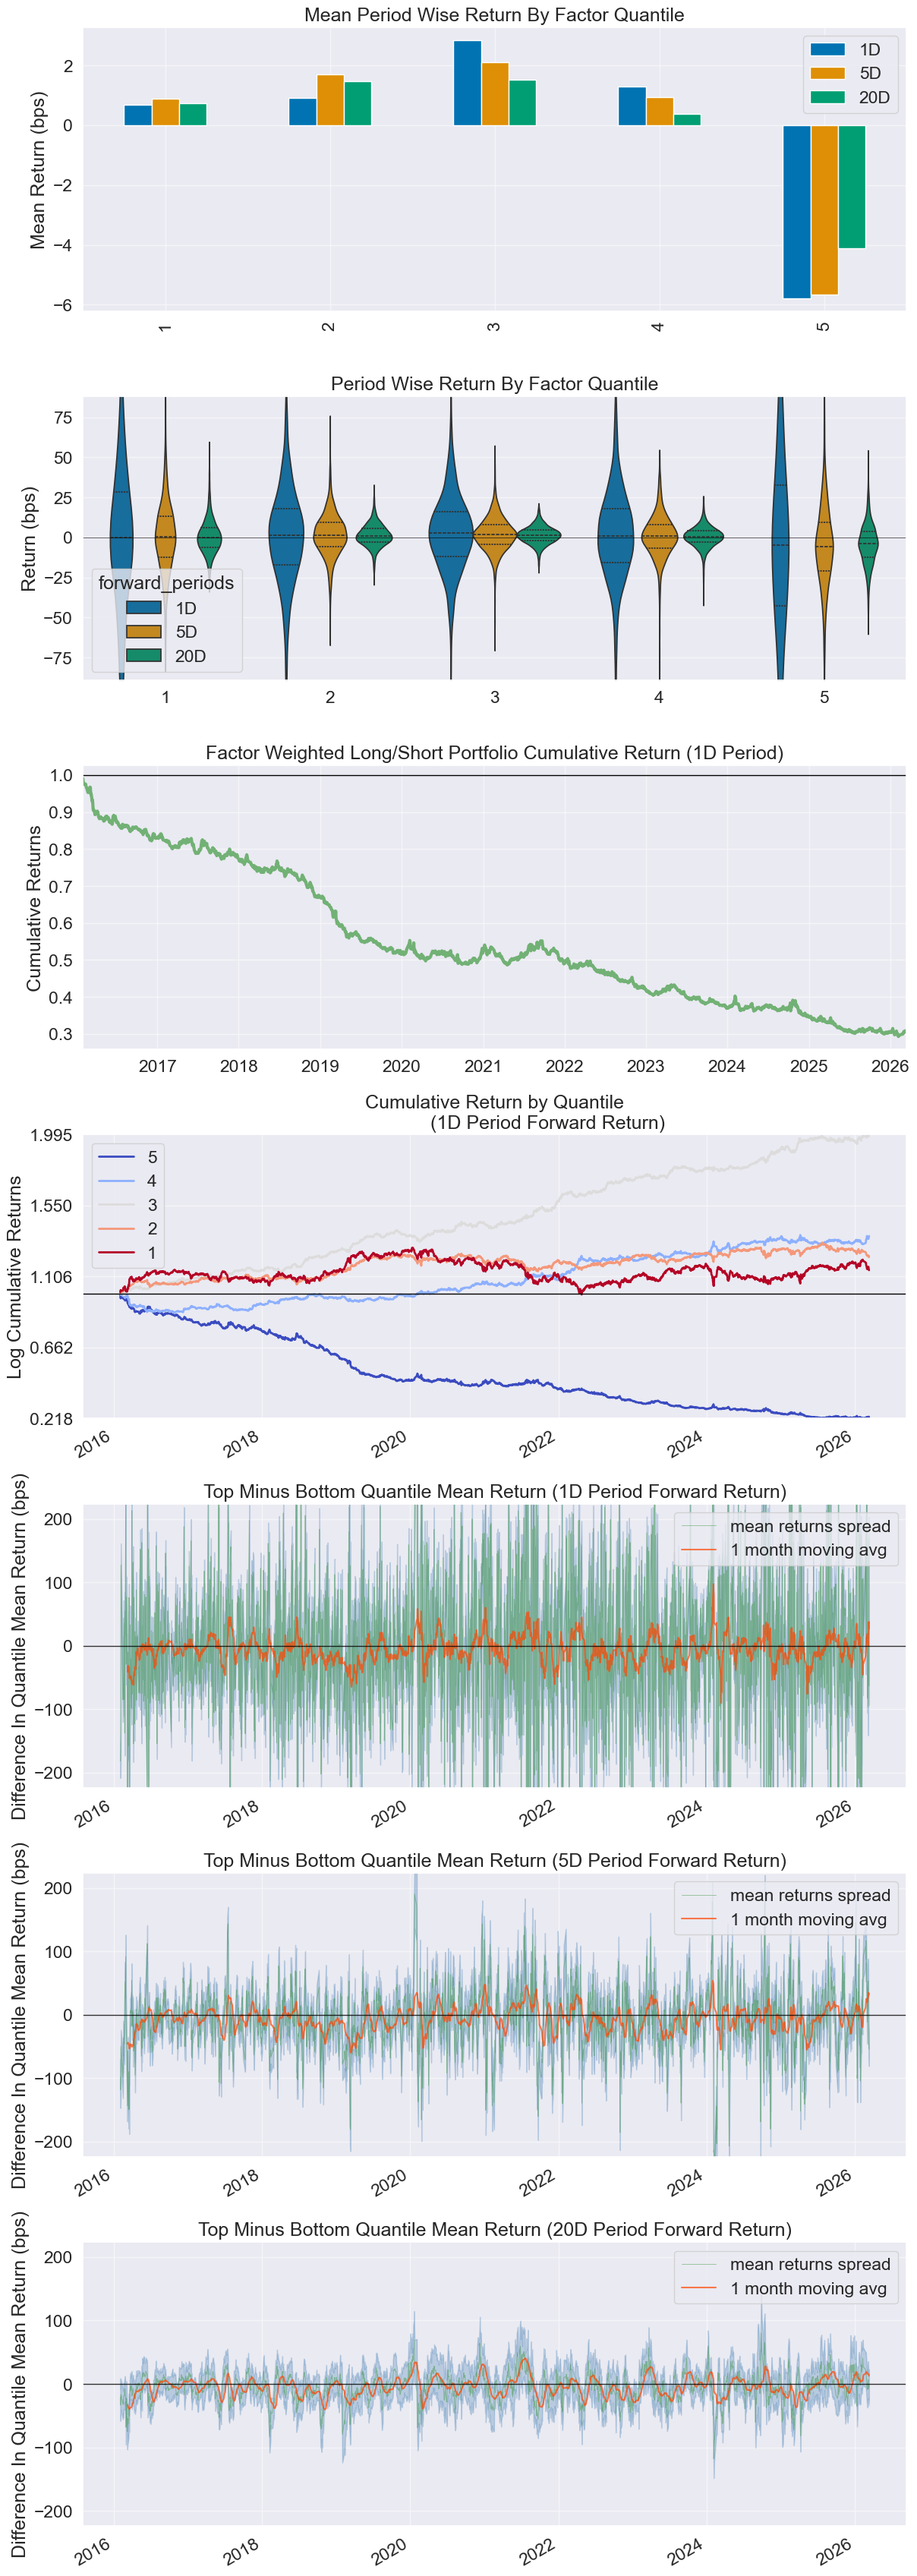

Information Analysis


,1D,5D,20D
IC Mean,-0.032,-0.048,-0.057
IC Std.,0.160,0.154,0.148
Risk-Adjusted IC,-0.199,-0.309,-0.388
t-stat(IC),-9.874,-15.324,-19.215
p-value(IC),0.000,0.000,0.000
IC Skew,-0.077,-0.199,-0.366
IC Kurtosis,0.253,0.504,0.220


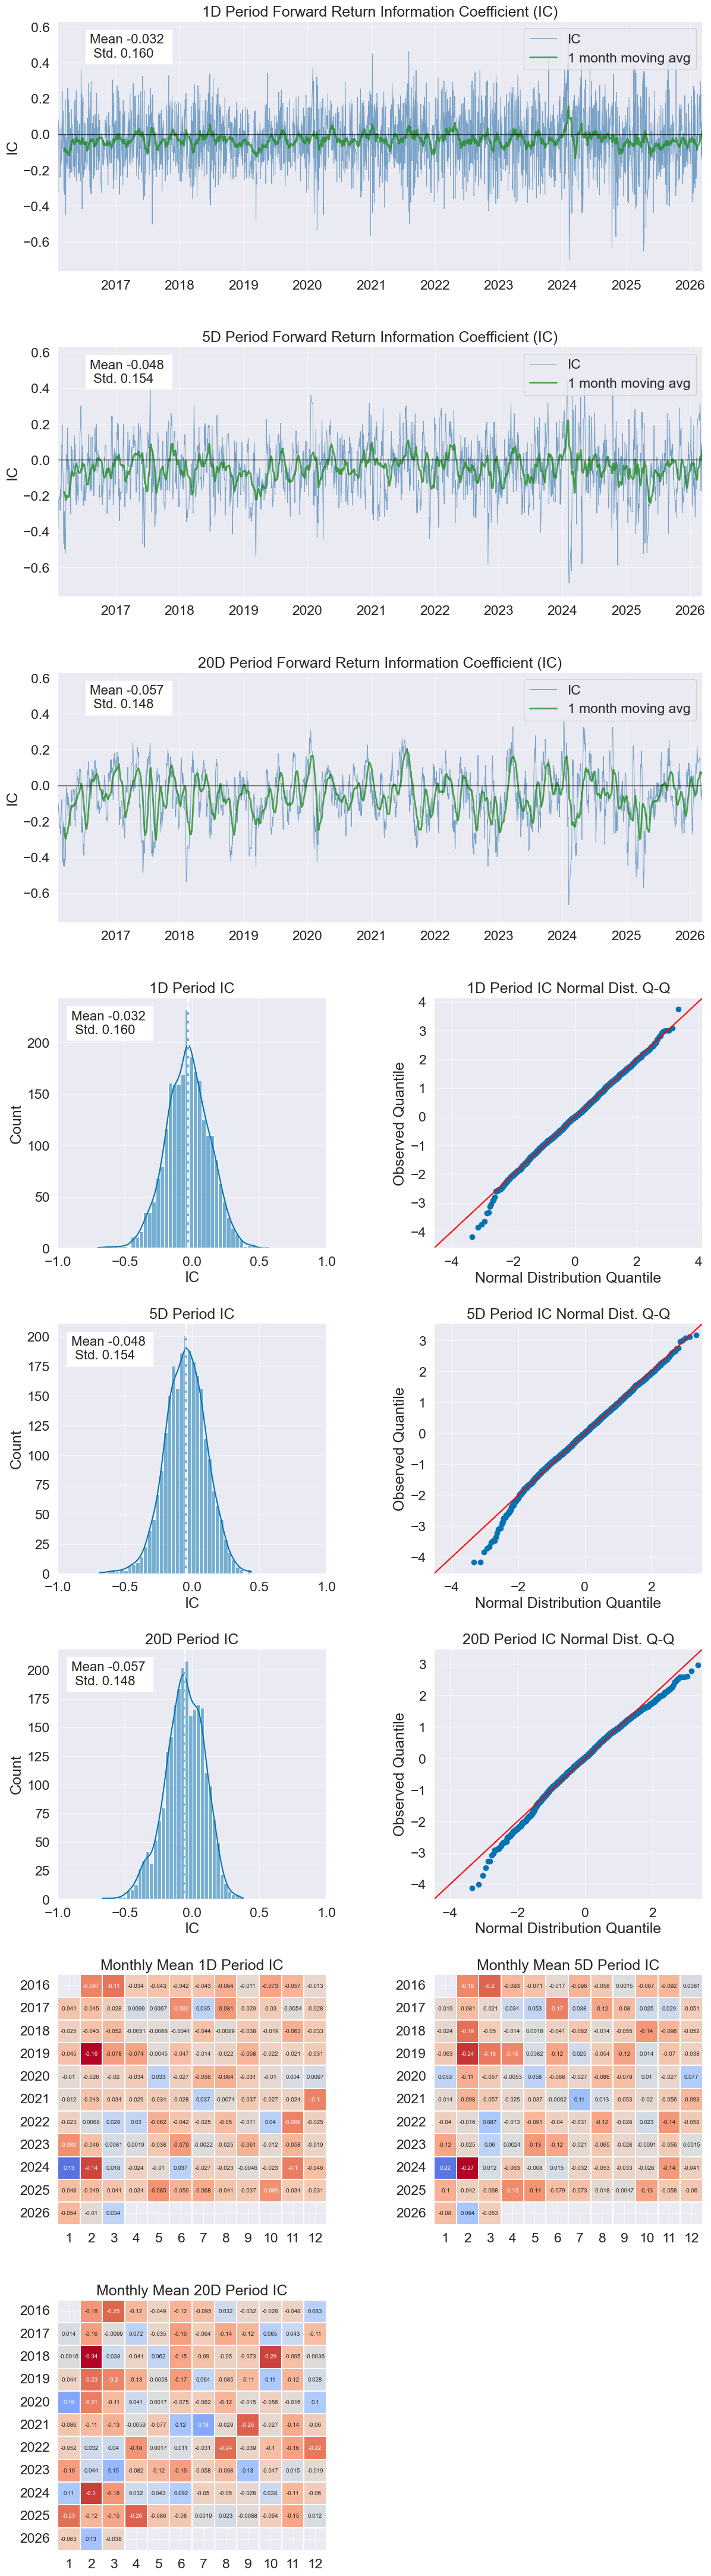

D:\anaconda3\envs\alphalens_env\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,20D
Quantile 1 Mean Turnover,0.187,0.423,0.819
Quantile 2 Mean Turnover,0.387,0.634,0.793
Quantile 3 Mean Turnover,0.420,0.661,0.776
Quantile 4 Mean Turnover,0.366,0.627,0.804
Quantile 5 Mean Turnover,0.161,0.376,0.785


,1D,5D,20D
Mean Factor Rank Autocorrelation,0.93,0.685,-0.062


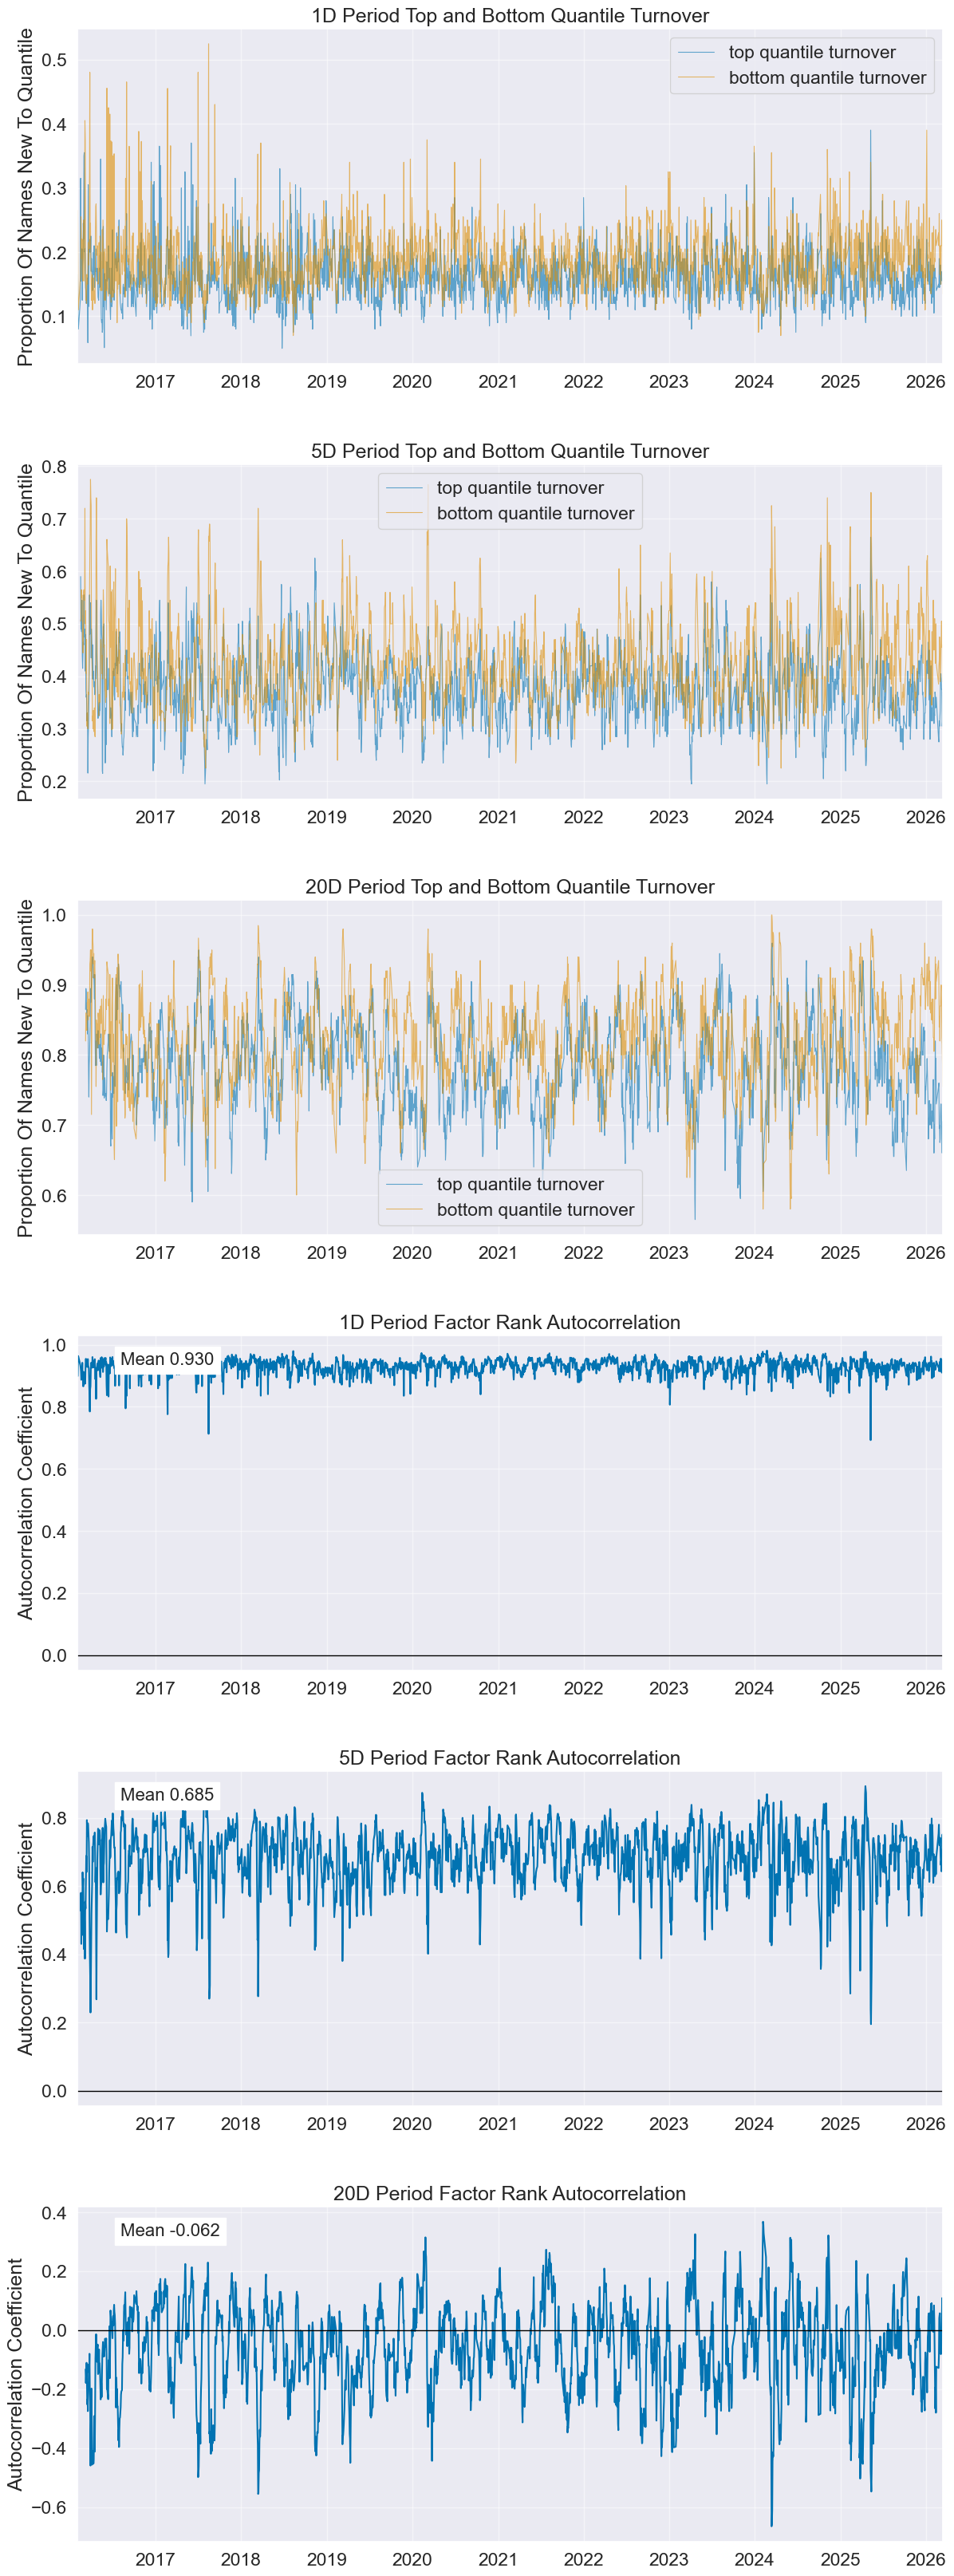

In [38]:
alphalens.tears.create_full_tear_sheet(
    clean_factor_and_forward_returns,
    long_short = True,
    group_neutral = False,  # 替换 group_adjust
    by_group = False
)